# Assignment 4

Arda Ntourali i6196749

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rsatoolbox
import torch
from scipy import stats
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader

from core import MODEL_CLASSES, SantoroDataset, extract_activations, load_yamnet_activations
from util import load_histories, plot_accuracy_history

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = ["waveform", "uninspired", "inspired", "crnn", "crnn_freqmask"]
N_RUNS = 5
rng = np.random.default_rng(0)
pd.set_option("display.max_rows", 100)

# setup dataset
dataset = SantoroDataset()
loader = DataLoader(dataset, batch_size=32, shuffle=False)

categories = np.array([name.split("_")[1] for name in dataset.filenames]) # s2_animal_1.wav - > animal and then all uniques
CATEGORY_NAMES = sorted(set(categories))
print("STG responses:", tuple(dataset.brain_responses.shape))
print(pd.Series(categories).value_counts().to_dict())

STG responses: (288, 5521)
{'animal': 48, 'music': 48, 'nature': 48, 'speech': 48, 'tools': 48, 'voice': 48}


In [17]:
RDM_METHODS = ["correlation", "euclidean"]


def make_rdms(activations):
    x = np.asarray(activations, dtype=np.float64).reshape(len(activations), -1)
    data = rsatoolbox.data.Dataset(x)
    return {method: rsatoolbox.rdm.calc_rdm(data, method=method) for method in RDM_METHODS}


def build_model(name, trained, run):
    torch.manual_seed(run)
    model = MODEL_CLASSES[name](num_classes=50)
    if trained:
        model.load_state_dict(torch.load(f"models/{name}_run{run}_best.pt", map_location="cpu"))
    return model.to(DEVICE)


def as_matrix(rdm):
    return rdm.get_matrices()[0]


brain_rdms = make_rdms(dataset.brain_responses.numpy())

rdms = {}
for name in MODELS:
    for state in ["untrained", "trained"]:
        for run in range(N_RUNS):
            model = build_model(name, state == "trained", run)
            for layer, activations in extract_activations(loader, model).items():
                rdms[(name, state, run, layer)] = make_rdms(activations.numpy())
for layer, activations in load_yamnet_activations().items():
    rdms[("yamnet", "pretrained", 0, layer)] = make_rdms(activations)
print(len(rdms), "RDM sets")

305 RDM sets


## Comparing models

We used Spearman Rho-a and Pearson correlation and cos similarity as a fallback.And compare the STG's from brain measurements to those from our models.

In [18]:
COMPARE_METHODS = ["rho-a", "corr", "cosine"]

rows = []
for (name, state, run, layer), model_rdms in rdms.items():
    for rdm_method in RDM_METHODS:
        for compare_method in COMPARE_METHODS:
            score = rsatoolbox.rdm.compare(model_rdms[rdm_method], brain_rdms[rdm_method], method=compare_method)[0, 0]
            rows.append(dict(model=name, state=state, run=run, layer=layer,
                             rdm=rdm_method, comparison=compare_method, score=score))
scores = pd.DataFrame(rows)
main = scores[(scores.rdm == "correlation") & (scores.comparison == "rho-a")]

category_rdm = rsatoolbox.rdm.RDMs((categories[:, None] != categories[None, :]).astype(float)[None])
category_score = rsatoolbox.rdm.compare(category_rdm, brain_rdms["correlation"], method="rho-a")[0, 0]
print(f"Categorical reference RDM vs STG: rho-a = {category_score:.3f}")

Categorical reference RDM vs STG: rho-a = 0.132


In [19]:
def t_ci(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return values.mean(), np.nan, np.nan
    half_width = stats.t.ppf(0.975, len(values) - 1) * stats.sem(values)
    return values.mean(), values.mean() - half_width, values.mean() + half_width


layer_summary = []
for (name, state, layer), group in main.groupby(["model", "state", "layer"], sort=False):
    mean, low, high = t_ci(group.score)
    layer_summary.append(dict(model=name, state=state, layer=layer, mean=mean, ci_low=low, ci_high=high))
layer_summary = pd.DataFrame(layer_summary)
layer_summary.round(3)

,model,state,layer,mean,ci_low,ci_high
0,waveform,untrained,hidden_layers.0,-0.064,-0.083,-0.045
1,waveform,untrained,hidden_layers.1,-0.096,-0.118,-0.073
2,waveform,untrained,hidden_layers.2,-0.083,-0.105,-0.060
3,waveform,untrained,hidden_layers.3,-0.075,-0.100,-0.051
4,waveform,untrained,hidden_layers.4,-0.052,-0.096,-0.008
5,waveform,untrained,classifier,-0.048,-0.097,0.001
6,waveform,trained,hidden_layers.0,-0.068,-0.087,-0.049
7,waveform,trained,hidden_layers.1,-0.031,-0.049,-0.013
8,waveform,trained,hidden_layers.2,-0.030,-0.050,-0.011
9,waveform,trained,hidden_layers.3,-0.029,-0.044,-0.013


### Depth profiles

Most of the plots are recreations of the ones from the original readme file. AI modifications were utilized while preparing the plots.

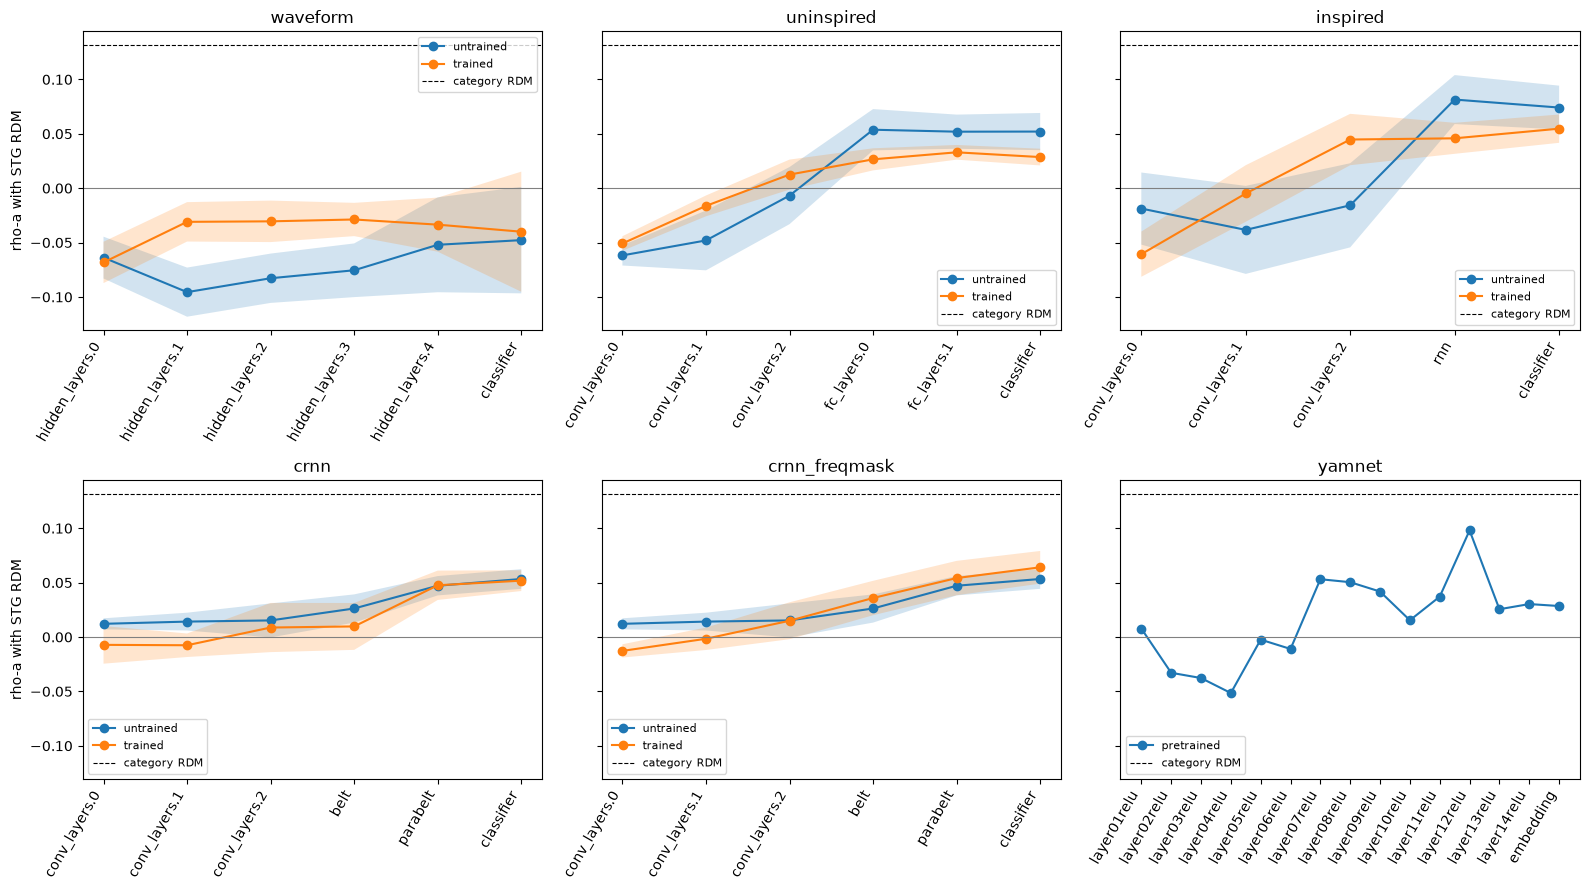

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
for ax, name in zip(axes.flat, MODELS + ["yamnet"]):
    for state in (["pretrained"] if name == "yamnet" else ["untrained", "trained"]):
        profile = layer_summary[(layer_summary.model == name) & (layer_summary.state == state)]
        x = np.arange(len(profile))
        ax.plot(x, profile["mean"], marker="o", label=state)
        ax.fill_between(x, profile.ci_low, profile.ci_high, alpha=0.2)
    ax.set_xticks(x, profile.layer, rotation=60, ha="right")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axhline(category_score, color="black", linestyle="--", linewidth=0.8, label="category RDM")
    ax.set_title(name)
    ax.legend(fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("rho-a with STG RDM")
fig.tight_layout()
fig.savefig(FIGURES / "layer_profiles.png", dpi=150)

### layers per model

In [21]:
trained_summary = layer_summary[layer_summary.state.isin(["trained", "pretrained"])]
best_layer = trained_summary.loc[trained_summary.groupby("model", sort=False)["mean"].idxmax()]
best_layer = dict(zip(best_layer.model, best_layer.layer))
best_layer

{'waveform': 'hidden_layers.3',
 'uninspired': 'fc_layers.1',
 'inspired': 'classifier',
 'crnn': 'classifier',
 'crnn_freqmask': 'classifier',
 'yamnet': 'layer12relu'}

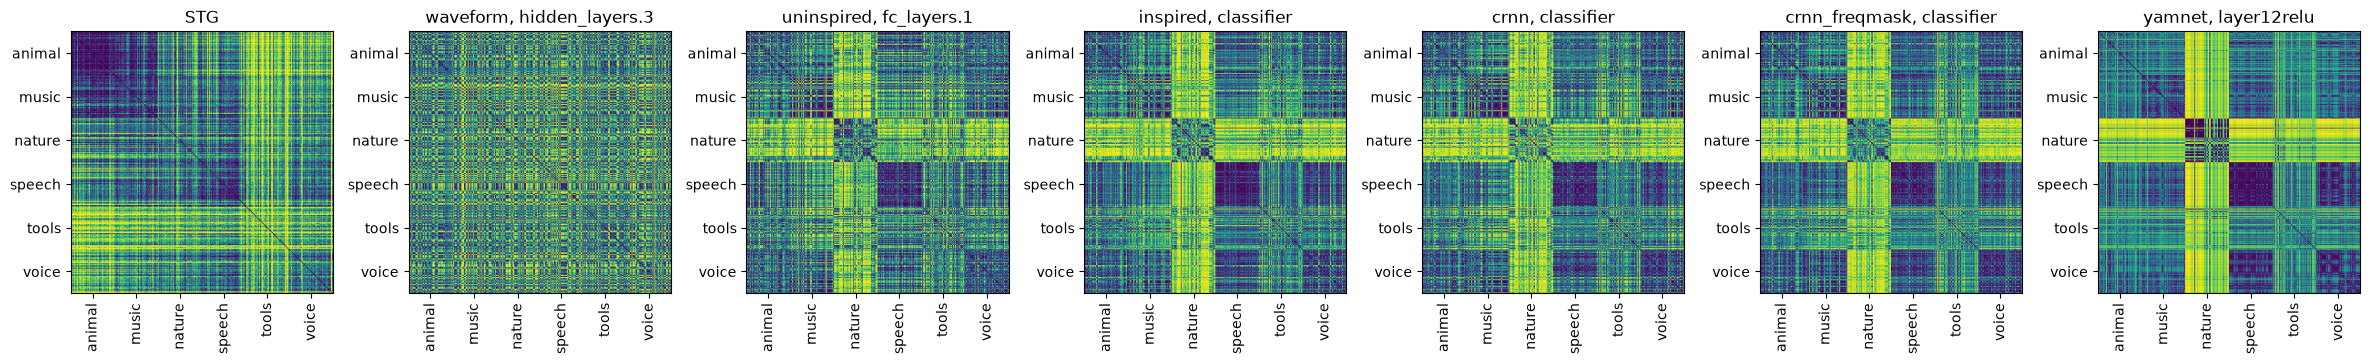

In [22]:
# RDMs of the STG and of the best layer of each model, sounds sorted by category, similar to like in readme and modified version of the plotters from util.py
order = np.argsort(categories, kind="stable")
examples = [("STG", brain_rdms["correlation"])]
examples += [(f"{name}, {best_layer[name]}", rdms[(name, "trained", 0, best_layer[name])]["correlation"]) for name in MODELS]
examples += [(f"yamnet, {best_layer['yamnet']}", rdms[("yamnet", "pretrained", 0, best_layer["yamnet"])]["correlation"])]

fig, axes = plt.subplots(1, len(examples), figsize=(3.4 * len(examples), 3.8))
for ax, (title, rdm) in zip(axes, examples):
    matrix = as_matrix(rdm)[np.ix_(order, order)]
    ax.imshow(stats.rankdata(matrix).reshape(matrix.shape), cmap="viridis")  # rank-transformed for display
    ax.set_title(title)
    ticks = [np.flatnonzero(categories[order] == c).mean() for c in CATEGORY_NAMES]
    ax.set_xticks(ticks, CATEGORY_NAMES, rotation=90)
    ax.set_yticks(ticks, CATEGORY_NAMES)
fig.tight_layout()
fig.savefig(FIGURES / "rdms.png", dpi=150)

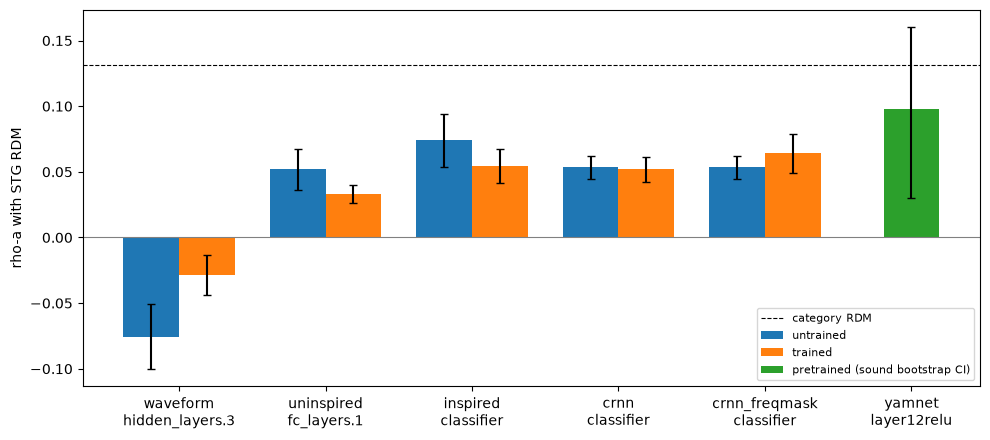

In [23]:
#rho-a with STG RDM per model trained/untrained/pretrained for yamnet
fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.38
for offset, state, color in [(-width / 2, "untrained", "tab:blue"), (width / 2, "trained", "tab:orange")]:
    part = best[best.state == state]
    x = np.arange(len(part)) + offset
    ax.bar(x, part["mean"], width, color=color, label=state)
    ax.errorbar(x, part["mean"], yerr=[part["mean"] - part.instance_ci_low, part.instance_ci_high - part["mean"]],
                fmt="none", color="black", capsize=3)
yamnet = best[best.model == "yamnet"].iloc[0]
x = len(MODELS)
ax.bar(x, yamnet["mean"], width, color="tab:green", label="pretrained (sound bootstrap CI)")
ax.errorbar(x, yamnet["mean"], yerr=[[yamnet["mean"] - yamnet.sound_ci_low], [yamnet.sound_ci_high - yamnet["mean"]]],
            fmt="none", color="black", capsize=3)
ax.axhline(category_score, color="black", linestyle="--", linewidth=0.8, label="category RDM")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(range(len(MODELS) + 1), [f"{m}\n{best_layer[m]}" for m in MODELS + ["yamnet"]])
ax.set_ylabel("rho-a with STG RDM")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "best_layer.png", dpi=150)

,model,val_acc,ci_low,ci_high
0,waveform,0.062,0.059,0.066
1,uninspired,0.303,0.286,0.320
2,inspired,0.419,0.413,0.425
3,crnn,0.394,0.379,0.409
4,crnn_freqmask,0.407,0.390,0.424


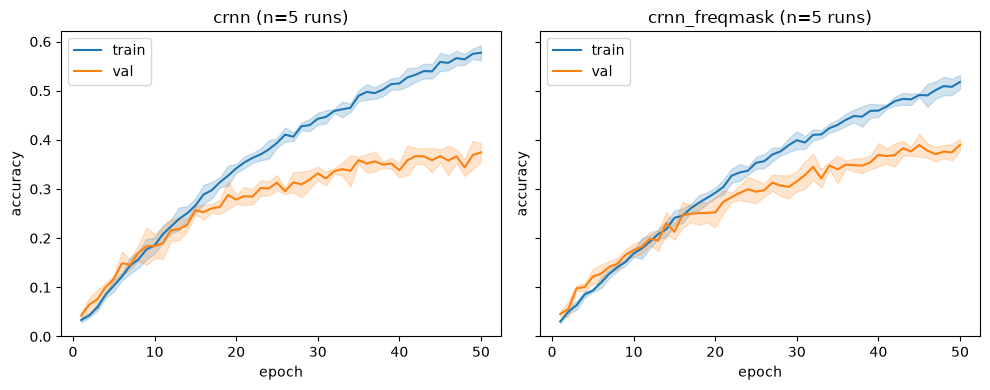

In [24]:
#compare model accuracy
accuracy = []
for name in MODELS:
    mean, low, high = t_ci([max(history["val_acc"]) for history in load_histories(Path("models"), name)])
    accuracy.append(dict(model=name, val_acc=mean, ci_low=low, ci_high=high))
display(pd.DataFrame(accuracy).round(3))

fig = plot_accuracy_history(Path("models"), ["crnn_freqmask", "crnn"])
fig.savefig(FIGURES / "crnn_training.png", dpi=150)

We can see that frequency masking does effectively boost the validation accuracy, which might imply that the model is better at recognizing the spectral patterns instead of just inferring from frequency alone. Still does not beat inspired model, but shows that frequency masking could be used with the inspired model to experiment whether it allows that model to generalize better too. I couldn't run that experiment due to time constraints.

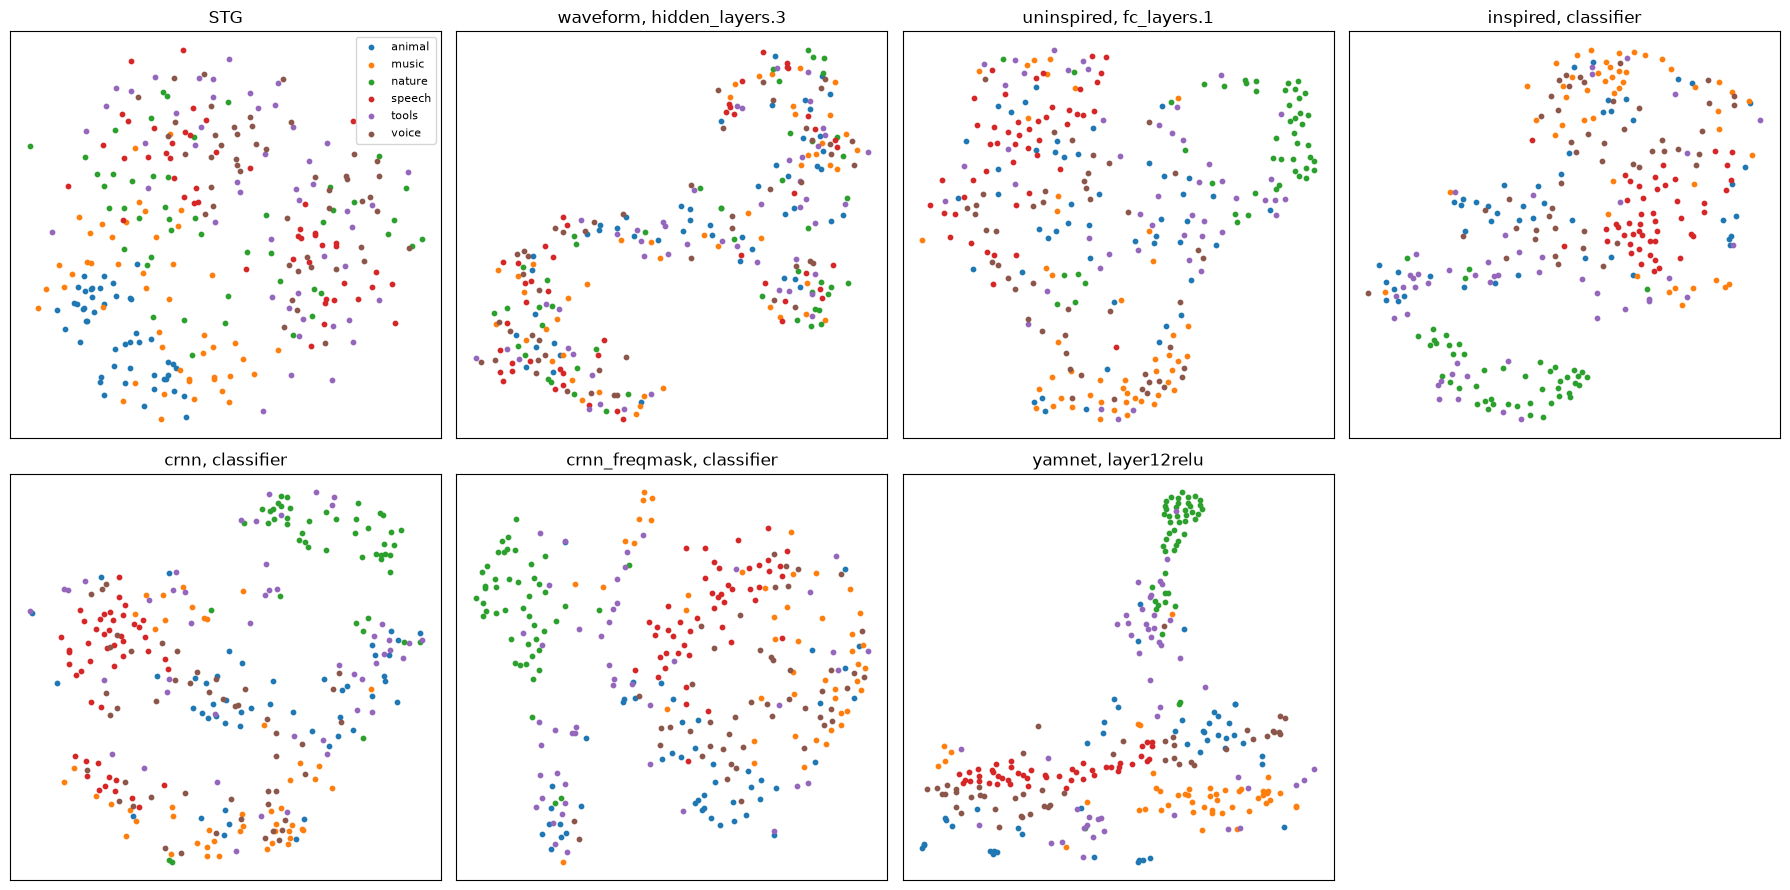

In [27]:
#T-sne util.py but incl. all the models and yamnet
panels = [("STG", brain_rdms["correlation"])]
panels += [(f"{name}, {best_layer[name]}", rdms[(name, "trained", 0, best_layer[name])]["correlation"]) for name in MODELS]
panels += [(f"yamnet, {best_layer['yamnet']}", rdms[("yamnet", "pretrained", 0, best_layer["yamnet"])]["correlation"])]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, rdm) in zip(axes.flat, panels):
    embedding = TSNE(metric="precomputed", init="random", perplexity=30, random_state=0).fit_transform(as_matrix(rdm))
    for i, category in enumerate(CATEGORY_NAMES):
        points = embedding[categories == category]
        ax.scatter(points[:, 0], points[:, 1], s=10, color=plt.cm.tab10(i), label=category)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
axes.flat[-1].axis("off")
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "tsne.png", dpi=150)